In [142]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import stats
# import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import importlib
import fit_thermal_rc_model
import sys
import datetime

sys.path.append(r"D:\Jupyter\CrystaLiZe\CrystaLiZe-SlowControlsData-main")
from crystalize_slowcontrolsdata.boxDownload import readBoxCSV

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")
mpl.rcdefaults()

# importlib.reload(fit_thermal_rc_model)
# from fit_thermal_rc_model import (
#     plot_fit,
#     plot_validation,
#     save_results,
#     save_validation_results,
#     validate_experiment_arrays,
#     print_validation_summary, 
# )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [143]:
def coldhead_power_with_efficiency(CH_temp, eff):
    # corrected coldhead power in cases where coldhead is < 100% efficient
    # ideally, 0 < eff <= 1
    a = 8.17430058
    b = 22.45378994
    power = a * np.sqrt(CH_temp - b)
    power = eff * power
    return power

In [144]:
# # 7c
# start_time = datetime.datetime(2026, 2, 28, 20, 30, 0)
# end_time = datetime.datetime(2026, 3, 2, 12, 0, 0)
# 7d
# start_time = datetime.datetime(2026, 3, 8, 3, 30, 0)
# end_time = datetime.datetime(2026, 3, 9, 6, 0, 0)
# 7e
# start_time = datetime.datetime(2026, 3, 10, 16, 30, 0)
# end_time = datetime.datetime(2026, 3, 11, 19, 30, 0)
# 7f
# start_time = datetime.datetime(2026, 3, 13, 8, 0, 0)
# end_time = datetime.datetime(2026, 3, 14, 11, 0, 0)
# 7g
# start_time = datetime.datetime(2026, 3, 17, 17, 17, 0)
# end_time = datetime.datetime(2026, 3, 18, 12, 20, 0)    
# 7e
start_time = datetime.datetime(2026, 3, 19, 10, 52, 0)
end_time = datetime.datetime(2026, 3, 22, 1, 40, 0)    
# # 7j
# start_time = datetime.datetime(2026, 3, 31, 15, 40, 0)
# end_time = datetime.datetime(2026, 4, 2, 3, 0, 0)
# # 7k
# start_time = datetime.datetime(2026, 4, 10, 4, 40, 0)
# end_time = datetime.datetime(2026, 4, 11, 19, 0, 0)

df = readBoxCSV(
    key="Lakeshore",
    timeCol="Time",
    start_time=start_time,
    end_time=end_time,
    download=True,
    return_df=True
)
# df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H_%M_%S", errors="coerce")
print(df.shape)


2026-03-18 16_35_02.csv: 25.4MB [00:00, 79.6MB/s]
2026-03-20 07_54_40.csv: 1.37MB [00:00, 25.0MB/s]
2026-03-20 10_19_27.csv: 21.0kB [00:00, 21.0MB/s]
2026-03-20 10_21_53.csv: 76.8MB [00:00, 103MB/s] 


(178064, 26)


In [145]:
# start_time = '2026-03-08 16:00:00'
# end_time = '2026-03-09 00:00:00'
# df = df[df['Time'].between(start_time, end_time)]
time = df['Time']
time_relative = df['Elapsed Time(s)'].to_numpy()
bot_flange = df['RTDD3 Temperature(K)'].to_numpy()
top_flange = df['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df['Heater1 Output(W)'].to_numpy()
Heater2 = df['Heater2 Output(W)'].to_numpy()
CH_temp = df['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)

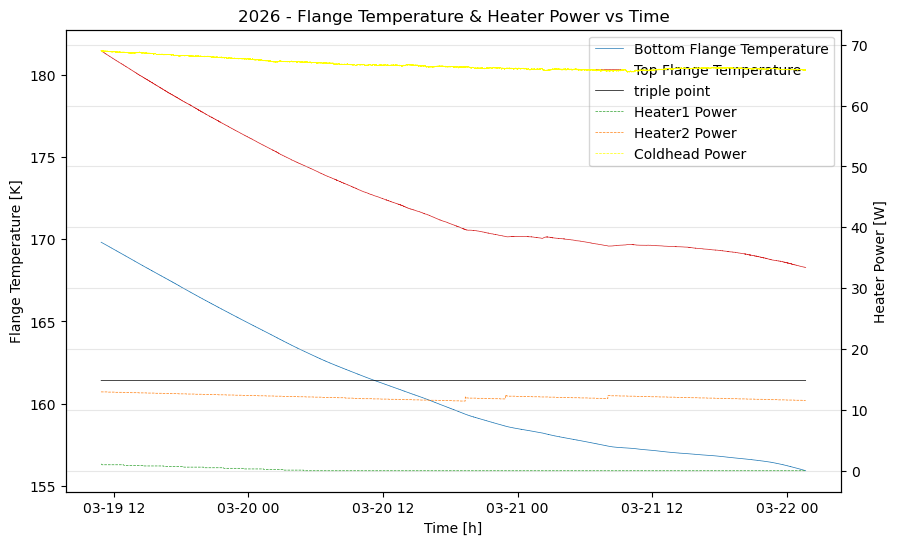

In [146]:
triple = [161.406] * len(time)

fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(time, bot_flange, color='tab:blue', linewidth=0.5, label='Bottom Flange Temperature')
line12 = ax1.plot(time, top_flange, color='tab:red', linewidth=0.5, label='Top Flange Temperature')
# line13 = ax1.plot(time, top_flange-bot_flange, color='purple', linewidth=0.5, label='Temperature difference')
line14 = ax1.plot(time, triple, color='black', linewidth=0.5, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(time, Heater1, color='tab:green', linestyle='--', linewidth=0.5, label='Heater1 Power')
line22 = ax2.plot(time, Heater2, color='tab:orange', linestyle='--', linewidth=0.5, label='Heater2 Power')
line23 = ax2.plot(time, CH_power, color='yellow', linestyle='--', linewidth=0.5, label='Coldhead Power')
# line24 = ax2.plot(time, Heateri0, color='black', linestyle='--', linewidth=0.5, label='i0 Power')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line14 + line21 + line22 + line23 # + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

title_string = "2026 - Flange Temperature & Heater Power vs Time"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

In [147]:
mask = (df['RTDD3 Temperature(K)'].to_numpy() > 161.406)
df_liquid = df[mask]
time = df_liquid['Time']
seconds = (time - time.iloc[0]).dt.total_seconds()

bot_flange = df_liquid['RTDD3 Temperature(K)'].to_numpy()
top_flange = df_liquid['RTDD4 Temperature(K)'].to_numpy()
Heater1 = df_liquid['Heater1 Output(W)'].to_numpy()
Heater2 = df_liquid['Heater2 Output(W)'].to_numpy()
CH_temp = df_liquid['RTDD5 Temperature(K)'].to_numpy()
CH_power = coldhead_power_with_efficiency(CH_temp, eff=1)
CH_power = np.asarray(CH_power, dtype=float)

In [148]:
print(time)

49842    2026-03-19 10:52:00
49843    2026-03-19 10:52:01
49844    2026-03-19 10:52:03
49845    2026-03-19 10:52:04
49846    2026-03-19 10:52:05
                 ...        
121511   2026-03-20 11:16:52
121512   2026-03-20 11:16:53
121513   2026-03-20 11:16:55
121514   2026-03-20 11:16:56
121515   2026-03-20 11:16:58
Name: Time, Length: 71674, dtype: datetime64[ns]


In [149]:
mass = 5.95 * 1000 # (g)
grad_T_bot = np.gradient(bot_flange, seconds, axis=None, edge_order=1)
grad_T_top = np.gradient(top_flange, seconds, axis=None, edge_order=1)
grad_T = (grad_T_bot + grad_T_top) / 2
I_LXe = grad_T * 0.1587 * mass
i0 = CH_power - Heater1 - Heater2 - I_LXe
print(i0)
print(np.max(i0))
print(np.min(i0))
print(np.median(i0))

[54.93953685 54.94462078 55.25312975 ... 55.01769255 54.94090601
 54.95727279]
nan
nan
nan


D:\Anaconda\Anaconda2022\lib\site-packages\numpy\lib\function_base.py:1084: RuntimeWarning: divide by zero encountered in true_divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
D:\Anaconda\Anaconda2022\lib\site-packages\numpy\lib\function_base.py:1085: RuntimeWarning: divide by zero encountered in true_divide
  b = (dx2 - dx1) / (dx1 * dx2)
D:\Anaconda\Anaconda2022\lib\site-packages\numpy\lib\function_base.py:1086: RuntimeWarning: divide by zero encountered in true_divide
  c = dx1 / (dx2 * (dx1 + dx2))
D:\Anaconda\Anaconda2022\lib\site-packages\numpy\lib\function_base.py:1092: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


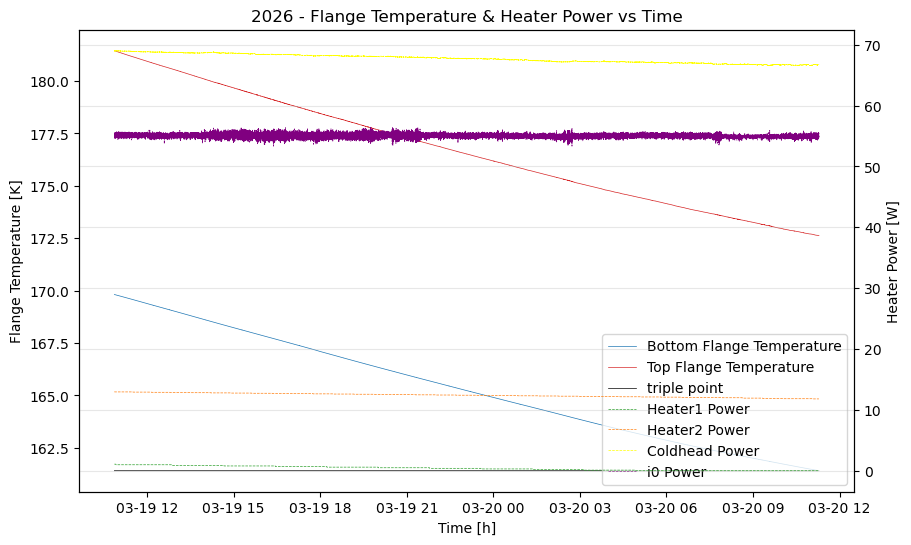

In [150]:
triple = [161.406] * len(time)

fig, ax1 = plt.subplots(figsize=(10, 6))

line11 = ax1.plot(time, bot_flange, color='tab:blue', linewidth=0.5, label='Bottom Flange Temperature')
line12 = ax1.plot(time, top_flange, color='tab:red', linewidth=0.5, label='Top Flange Temperature')
# line13 = ax1.plot(time, top_flange-bot_flange, color='purple', linewidth=0.5, label='Temperature difference')
line14 = ax1.plot(time, triple, color='black', linewidth=0.5, label='triple point')

ax1.set_xlabel('Time [h]')
ax1.set_ylabel('Flange Temperature [K]')
# ax1.tick_params(axis='y', labelcolor='tab:blue')  
ax2 = ax1.twinx()

line21 = ax2.plot(time, Heater1, color='tab:green', linestyle='--', linewidth=0.5, label='Heater1 Power')
line22 = ax2.plot(time, Heater2, color='tab:orange', linestyle='--', linewidth=0.5, label='Heater2 Power')
line23 = ax2.plot(time, CH_power, color='yellow', linestyle='--', linewidth=0.5, label='Coldhead Power')
line24 = ax2.plot(time, i0, color='purple', linestyle='--', linewidth=0.5, label='i0 Power')

ax2.set_ylabel('Heater Power [W]')
# ax2.tick_params(axis='y', labelcolor='tab:red')

lines = line11 + line12 + line14 + line21 + line22 + line23 + line24
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

title_string = "2026 - Flange Temperature & Heater Power vs Time"
plt.title(title_string)

plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

slope: 0.0244
intercept: 50.7149
R²: 0.4186


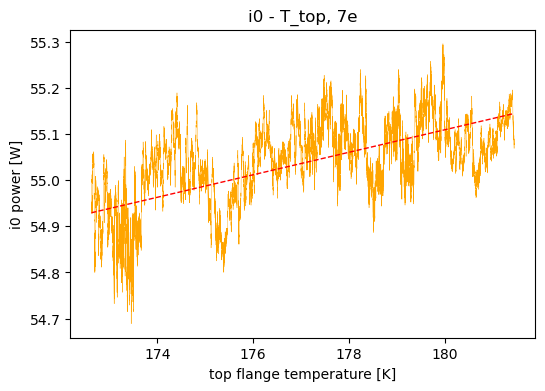

In [151]:
sort = np.argsort(top_flange)
import numpy as np

window_size = 100 
i0_smooth = pd.Series(i0).rolling(window=window_size, center=True, min_periods=1).mean().to_numpy()

from scipy import stats
res = stats.linregress(top_flange, i0_smooth)
print(f"slope: {res.slope:.4f}")
print(f"intercept: {res.intercept:.4f}")
print(f"R²: {res.rvalue**2:.4f}")
# print(f"p-value: {res.pvalue:.4e}")

i0_calc = top_flange * res.slope + res.intercept
plt.figure(figsize = (6, 4))
plt.plot(top_flange[sort], i0_smooth[sort], color="orange", linewidth=0.3)
plt.plot(top_flange[sort], i0_calc[sort], 'r--', linewidth=1)
plt.xlabel("top flange temperature [K]")
plt.ylabel("i0 power [W]")
plt.title("i0 - T_top, 7e")
# plt.xlim([175.4, 175.6])
plt.show()